In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# IPL 2025 Batting Performance Prediction

Total data points: 122
Training samples: 97
Testing samples: 25

--- Model Performance ---
R² Score: 0.8531
Mean Absolute Error: 10.9355


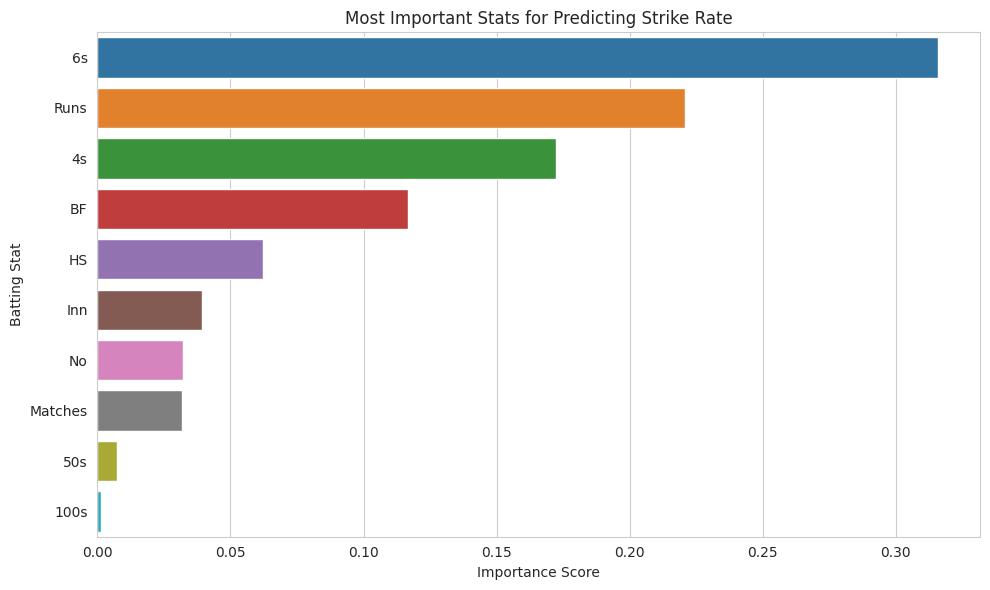

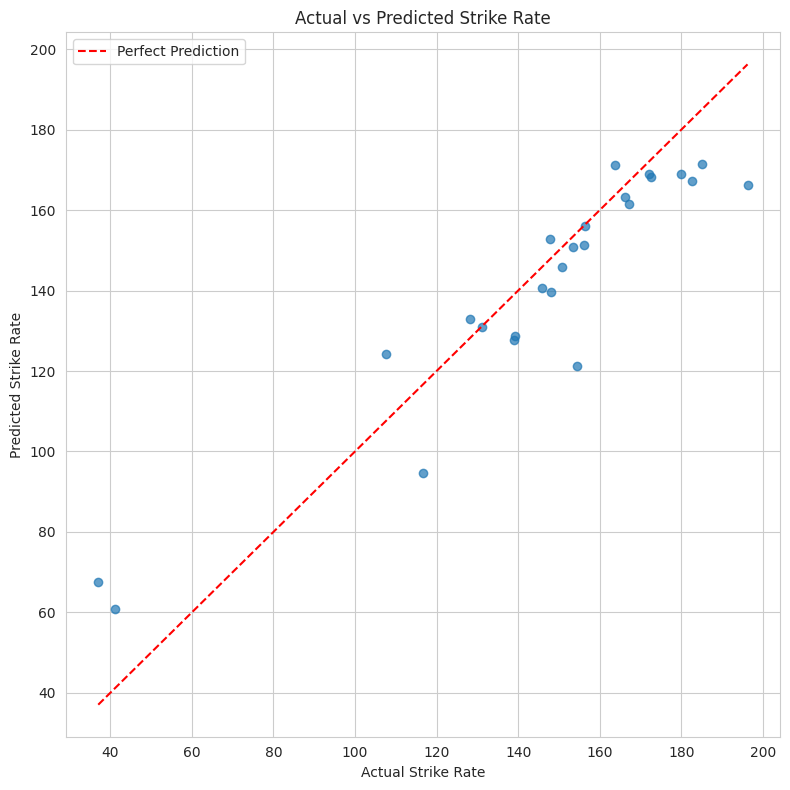


Project completed successfully!
Charts saved as PNG files.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
sns.set_style("whitegrid")
data_table = pd.read_csv("/kaggle/input/ipl-2025/IPL2025Batters.csv")
data_table['HS'] = (
    data_table['HS']
    .astype(str)
    .str.replace('*', '', regex=False)
    .astype(int)
)
data_table['AVG'] = data_table['AVG'].replace('-', '0.0').astype(float)
reliable_data = data_table[data_table['BF'] > 10].copy()
input_stats = ['Runs', 'Matches', 'Inn', 'No', 'HS', 'BF', '100s', '50s', '4s', '6s']
target = 'SR'
X = reliable_data[input_stats]
Y = reliable_data[target]
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
print(f"Total data points: {len(reliable_data)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
r2 = r2_score(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
print("\n--- Model Performance ---")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
feature_importance = pd.Series(
    model.feature_importances_,
    index=input_stats
).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)
plt.title("Most Important Stats for Predicting Strike Rate")
plt.xlabel("Importance Score")
plt.ylabel("Batting Stat")
plt.tight_layout()
plt.savefig("chart_1_feature_importances.png")
plt.show()
plt.figure(figsize=(8, 8))
plt.scatter(Y_test, Y_pred, alpha=0.7)
min_val = min(Y_test.min(), Y_pred.min())
max_val = max(Y_test.max(), Y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
plt.xlabel("Actual Strike Rate")
plt.ylabel("Predicted Strike Rate")
plt.title("Actual vs Predicted Strike Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("chart_2_actual_vs_predicted.png")
plt.show()
print("\nProject completed successfully!")
print("Charts saved as PNG files.")